# Syllable usage statistics

Workflow for MoSeq syllable analysis after you have:
1. `stats_df.csv` and `moseq_df.csv` from a fitted model
2. Syllable behavior category labels (Excel)

**Edit the settings cell first**, then run the notebook to load data, compute usage / entropy tables, and save figures.


## 1. Experiment settings

Change paths, treatments, timepoints, sex codes, and syllable categories to match your study.
Group names are expected as `{treatment}_{timepoint}_{sex}` (e.g. `cort_b2_m`).


In [1]:
import os
import sys
from os.path import join
from pathlib import Path

# Ensure repo root is on sys.path when the notebook is the working directory
REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from moseq_analysis import ExperimentConfig, apply_journal_style

# Paths
DATA_DIR = '/Users/mohanyang/Desktop/moseq/final_model_kappa_40000000'
LABELS_XLSX = '/Users/mohanyang/Desktop/moseq/Mo-seq syllable behavior labeling.xlsx'
LABELS_SHEET = 'Copy of Kaitlyn + Steve (KH)'

# Experiment design
TREATMENTS = ('cort', 'veh')
TIME_ORDER = ('b2', 'wk1', 'wk2', 'wk3', 'washout')
TIMEPOINT_LABELS = {
    'b2': 'Baseline',
    'wk1': 'Week 1',
    'wk2': 'Week 2',
    'wk3': 'Week 3',
    'washout': 'Washout',
}
SEX_CODES = {'m': 'male', 'f': 'female'}

VALID_SYLLABLE_CATEGORIES = {
    'locomotion', 'exploratory', 'grooming', 'immobility', 'hesitation',
}

# Optional: merge male/female by stripping _m/_f suffixes
COMBINE_SEX_GROUPS = False
MAX_SYLLABLE_ID = 54

# Treatment x sex time color scales (one list per timepoint, same order as TIME_ORDER)
TIME_COLOR_PALETTES = {
    ('cort', 'male'): ['#472a7a', '#33628d', '#21918c', '#3fbc73', '#b0dd2f'],
    ('cort', 'female'): ['#6a00a8', '#9410a2', '#cc4778', '#f0804e', '#fdc627'],
    ('veh', 'male'): ['#000000', '#404040', '#737373', '#a6a6a6', '#d9d9d9'],
    ('veh', 'female'): ['#5c3317', '#8b5a2b', '#a67c52', '#c4a484', '#e6d5c3'],
}

cfg = ExperimentConfig(
    data_dir=DATA_DIR,
    labels_xlsx=LABELS_XLSX,
    labels_sheet=LABELS_SHEET,
    figures_dir=join(os.getcwd(), 'figures'),
    fingerprint_plot_dir=join(os.getcwd(), 'figures'),
    transition_matrix_dir=DATA_DIR,
    combine_sex_groups=COMBINE_SEX_GROUPS,
    max_syllable_id=MAX_SYLLABLE_ID,
    treatments=TREATMENTS,
    time_order=TIME_ORDER,
    timepoint_labels=TIMEPOINT_LABELS,
    sex_codes=SEX_CODES,
    valid_syllable_categories=VALID_SYLLABLE_CATEGORIES,
    time_color_palettes=TIME_COLOR_PALETTES,
)

apply_journal_style()
print('Figures ->', cfg.figures_dir)
print('Treatments:', cfg.treatments)
print('Timepoints:', cfg.time_order)


/opt/miniconda3/envs/moseq2-app/lib/python3.7/site-packages/sklearn/utils/validation.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LARGE_SPARSE_SUPPORTED = LooseVersion(scipy_version) >= '0.14.0'


Figures -> /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures
Treatments: ('cort', 'veh')
Timepoints: ('b2', 'wk1', 'wk2', 'wk3', 'washout')


## 2. Imports


In [2]:
import importlib
import moseq_analysis
import moseq_analysis.config
import moseq_analysis.data
import moseq_analysis.fingerprint
import moseq_analysis.grouping
import moseq_analysis.plots
import moseq_analysis.style

for _mod in (
    moseq_analysis.config,
    moseq_analysis.style,
    moseq_analysis.grouping,
    moseq_analysis.data,
    moseq_analysis.plots,
    moseq_analysis.fingerprint,
    moseq_analysis,
):
    importlib.reload(_mod)

from moseq_analysis import (
    build_group_usage_tables,
    build_usage_by_mouse,
    list_transition_matrix_files,
    load_stats_and_labels,
    load_syllable_category_dict,
    maybe_combine_sex_groups,
    plot_syllable_usage_diff,
    plot_transition_matrix,
    run_fingerprint_for_treatment,
)


## 3. Load data and syllable labels


In [3]:
stats_df, syllable_labels = load_stats_and_labels(cfg)
syllable_dict = load_syllable_category_dict(syllable_labels)
stats_df = maybe_combine_sex_groups(stats_df, cfg)
syllable_labels.head()


stats_df: 26,977 rows x 90 columns
Unique groups: 65
Mapped 50 syllables to categories
Sex-separated groups: 65 unique groups
Groups: ['cort_b1_f', 'cort_b1_m', 'cort_b2_f', 'cort_b2_m', 'cort_ket_48h_f', 'cort_ket_48h_m', 'cort_ket_72h_f', 'cort_ket_72h_m', 'cort_ket_b1_f', 'cort_ket_b1_m', 'cort_ket_b2_f', 'cort_ket_b2_m', 'cort_ket_wk1_f', 'cort_ket_wk1_m', 'cort_sal_48h_f', 'cort_sal_48h_m', 'cort_sal_72h_f', 'cort_sal_72h_m', 'cort_sal_b1_f', 'cort_sal_b1_m', 'cort_sal_b2_f', 'cort_sal_b2_m', 'cort_sal_wk1_f', 'cort_sal_wk1_m', 'cort_washout_f', 'cort_washout_m', 'cort_wk1_f', 'cort_wk1_m', 'cort_wk2_f', 'cort_wk2_m', 'cort_wk3_f', 'cort_wk3_m', 'veh_b1_f', 'veh_b1_m', 'veh_b2_f', 'veh_b2_m', 'veh_ket_48h_f', 'veh_ket_48h_m', 'veh_ket_72h_f', 'veh_ket_72h_m', 'veh_ket_b1_f', 'veh_ket_b1_m', 'veh_ket_b2_f', 'veh_ket_b2_m', 'veh_ket_washout_f', 'veh_ket_wk1_f', 'veh_ket_wk1_m', 'veh_sal_48h_f', 'veh_sal_48h_m', 'veh_sal_72h_f', 'veh_sal_72h_m', 'veh_sal_b1_f', 'veh_sal_b1_m', 'veh_s

,syllable short id,syllable id,prior,general category,sub category,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,0.0,NaN,I - passive (neutral),immobility,I - tense (scrunched),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,NaN,E - active (rear),exploratory,E - fall from high rear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,NaN,E - pivot left in place,exploratory,E - stationary sniffing around,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,NaN,NaN,exploratory,E - pivot clockwise in place,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,NaN,NaN,grooming,G - fragmented only face groom,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Usage by mouse and Shannon entropy


In [4]:
usage_by_mouse, entropy_by_group = build_usage_by_mouse(stats_df)
entropy_by_group


,group,entropy_mean,entropy_sd,n_mice
0,cort_b1_f,4.609544,0.125288,13
1,cort_b1_m,4.705443,0.219551,12
2,cort_b2_f,4.720685,0.137159,13
3,cort_b2_m,4.864631,0.185032,12
4,cort_ket_48h_f,5.015264,0.160042,6
...,...,...,...,...
60,veh_wk1_m,4.875752,0.246846,13
61,veh_wk2_f,4.934522,0.102459,13
62,veh_wk2_m,4.753502,0.332122,12
63,veh_wk3_f,5.004840,0.096968,10


## 5. Group-level usage mean / SEM tables


In [5]:
group_usage_stats, pivot_mean, pivot_sem = build_group_usage_tables(stats_df, cfg)
pivot_mean.head()


group_usage_stats: (3445, 6)
usage_mean_by_group: (53, 65)


group,cort_b1_f,cort_b1_m,cort_b2_f,cort_b2_m,cort_ket_48h_f,cort_ket_48h_m,cort_ket_72h_f,cort_ket_72h_m,cort_ket_b1_f,cort_ket_b1_m,...,veh_sal_wk1_f,veh_sal_wk1_m,veh_washout_f,veh_washout_m,veh_wk1_f,veh_wk1_m,veh_wk2_f,veh_wk2_m,veh_wk3_f,veh_wk3_m
syllable,,,,,,,,,,,,,,,,,,,,,
0,0.004419,0.041071,0.008714,0.074211,0.043372,0.087575,0.037613,0.088906,0.027768,0.117035,...,0.020271,0.088988,0.024164,0.104964,0.015338,0.092632,0.021815,0.088644,0.025787,0.109284
1,0.036127,0.071050,0.027475,0.050733,0.028738,0.061319,0.033607,0.053126,0.028585,0.043442,...,0.036935,0.054006,0.029371,0.047497,0.032331,0.050209,0.031195,0.054175,0.029279,0.045318
2,0.001494,0.078970,0.002009,0.090694,0.017038,0.052469,0.020955,0.058211,0.014813,0.054450,...,0.013990,0.047130,0.013631,0.066592,0.005003,0.066239,0.006666,0.060361,0.010824,0.066568
3,0.064879,0.010329,0.059787,0.007365,0.064096,0.004677,0.069645,0.007340,0.055156,0.005972,...,0.060773,0.003564,0.069160,0.006605,0.071505,0.011030,0.072959,0.007162,0.067672,0.007320
4,0.049439,0.007391,0.045981,0.005162,0.042930,0.006041,0.042759,0.005551,0.050032,0.006177,...,0.052633,0.007449,0.057704,0.005322,0.062767,0.012212,0.059525,0.008170,0.059552,0.006679


## 6. Syllable usage figures

Each call below is one `plot_syllable_usage_diff`. Edit `groups`, `categories`, `sort_by`, or `save_path` as needed.
Shared defaults: sort by CORT female baseline vs washout, exclude syllable 29, `y_max=0.16`.


Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_female.eps


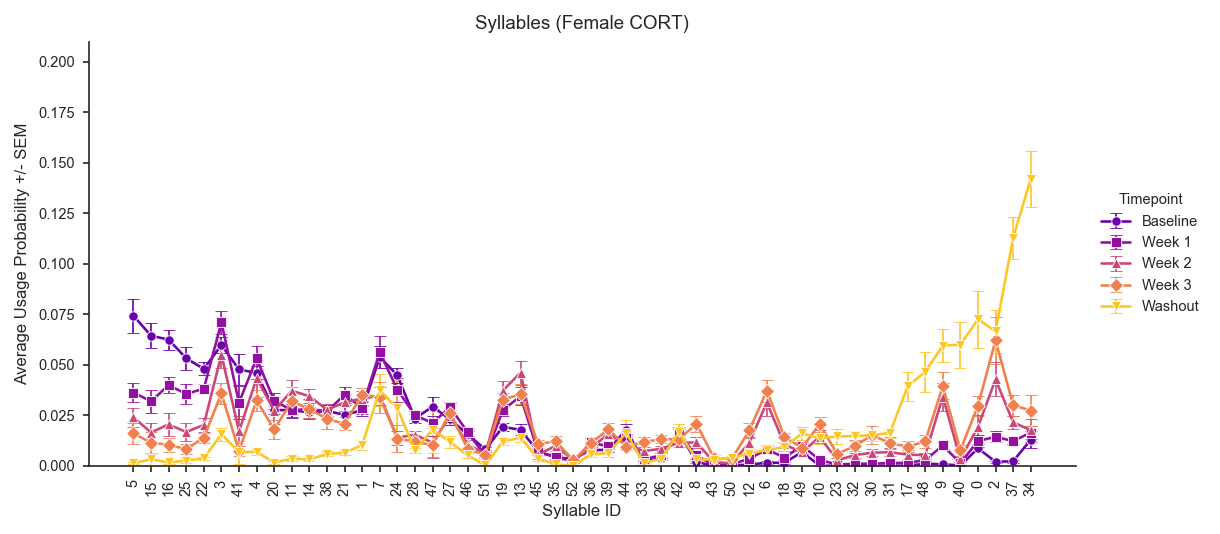

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_male.eps


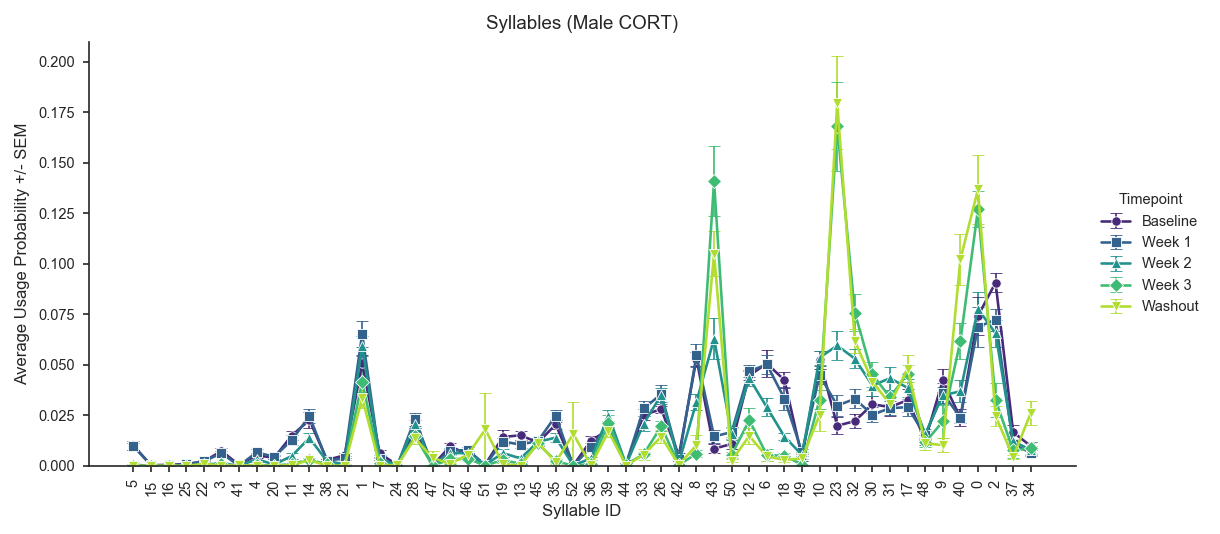

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_female.eps


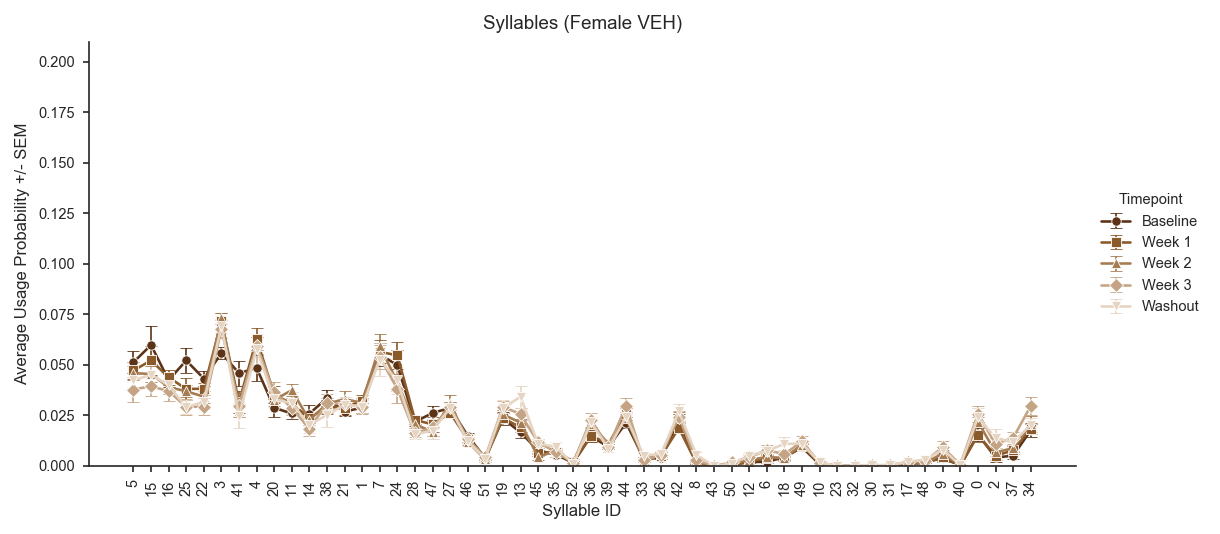

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_male.eps


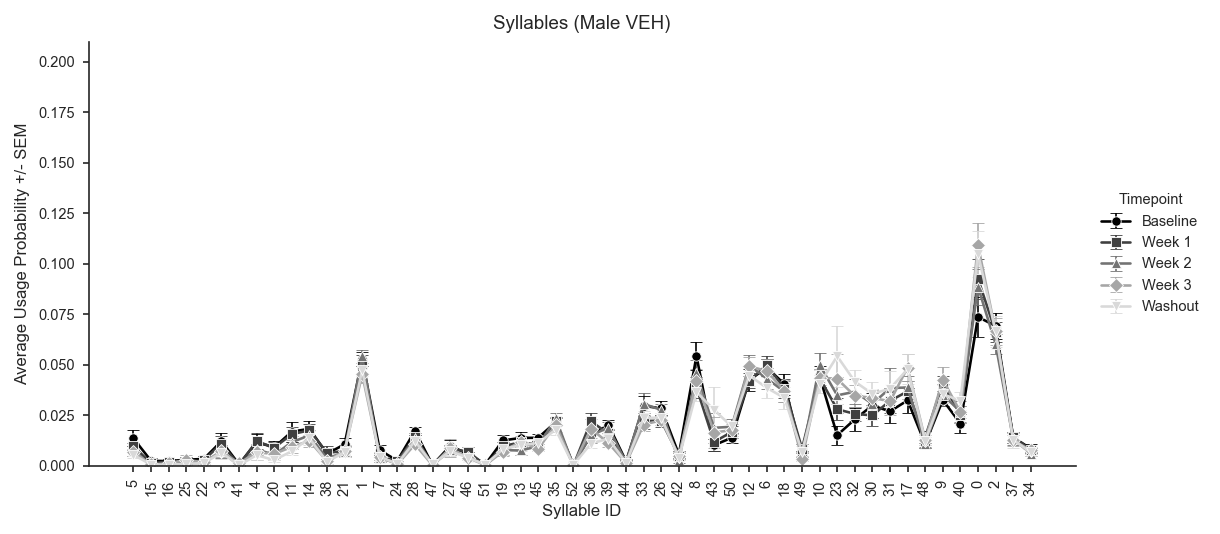

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/exploratory_female.eps


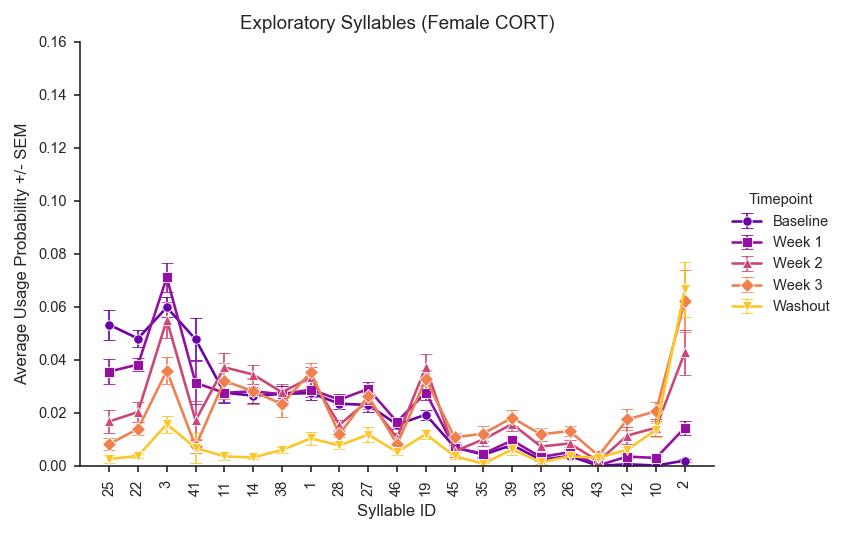

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/exploratory_male.eps


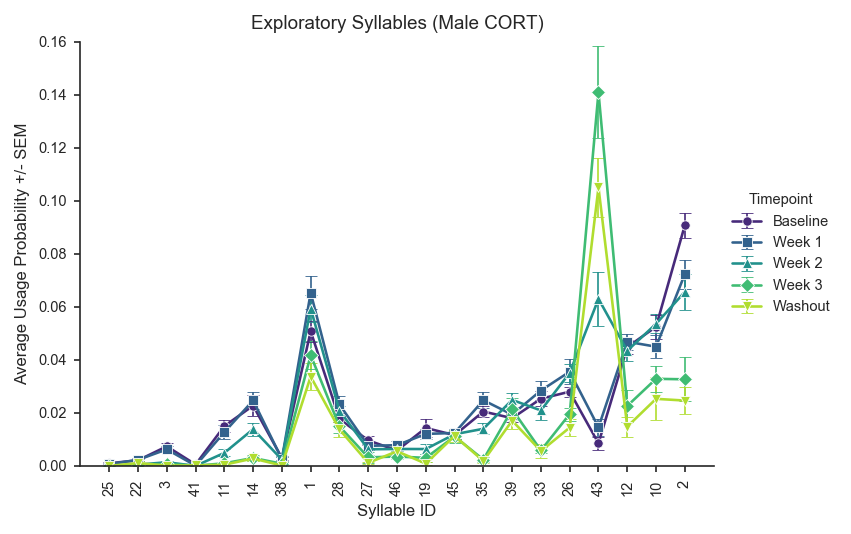

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/locomotion_female.eps


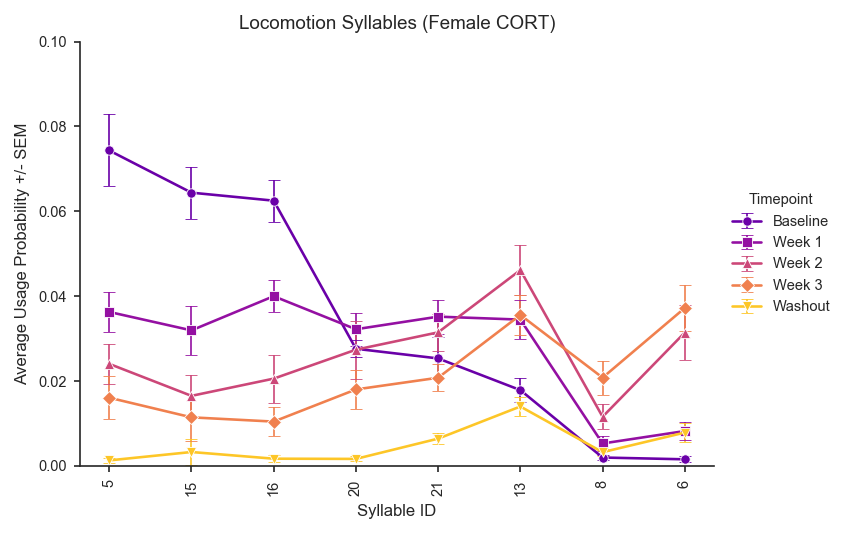

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/locomotion_male.eps


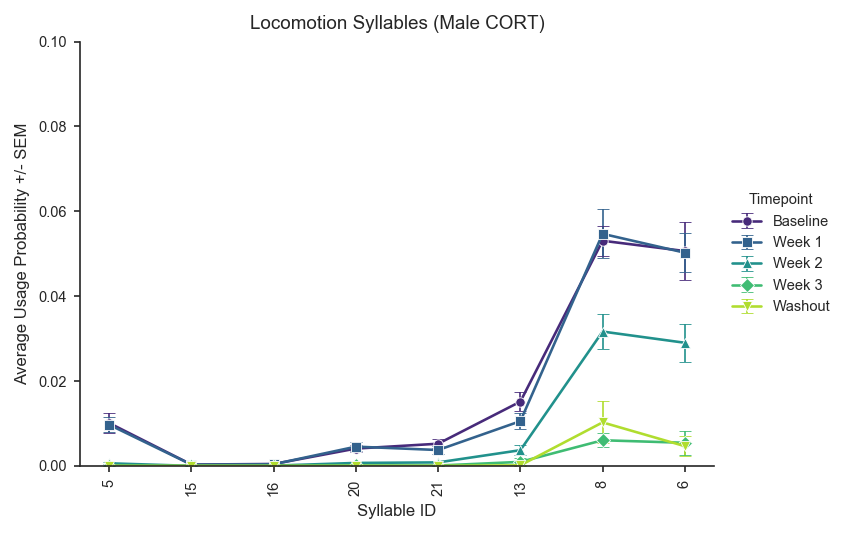

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/grooming_female.eps


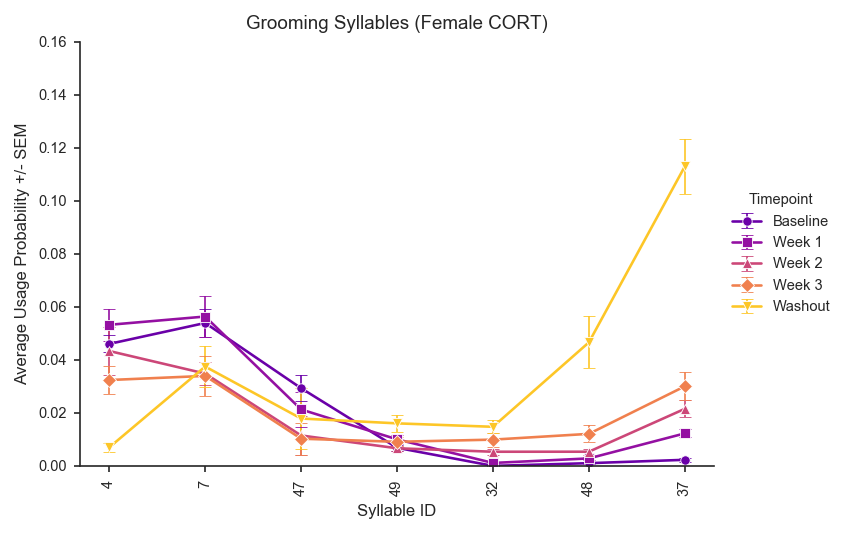

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/grooming_male.eps


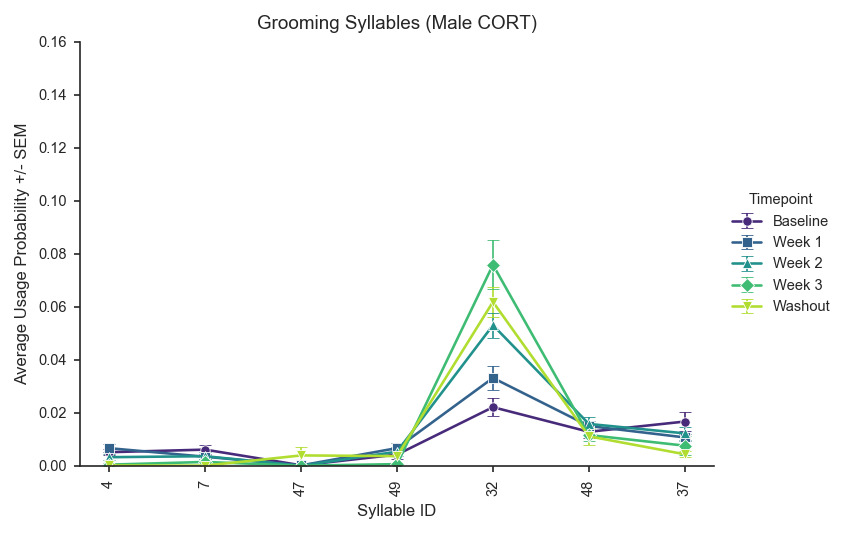

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/immobility_female.eps


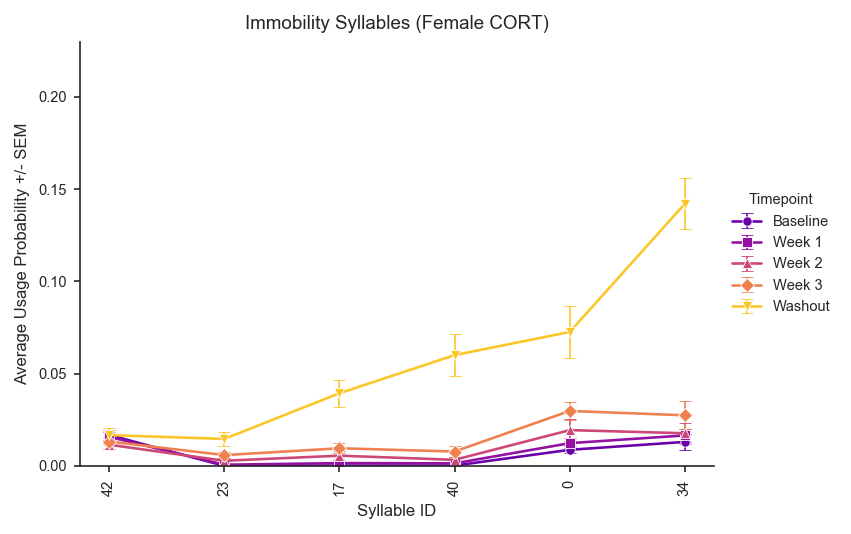

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/immobility_male.eps


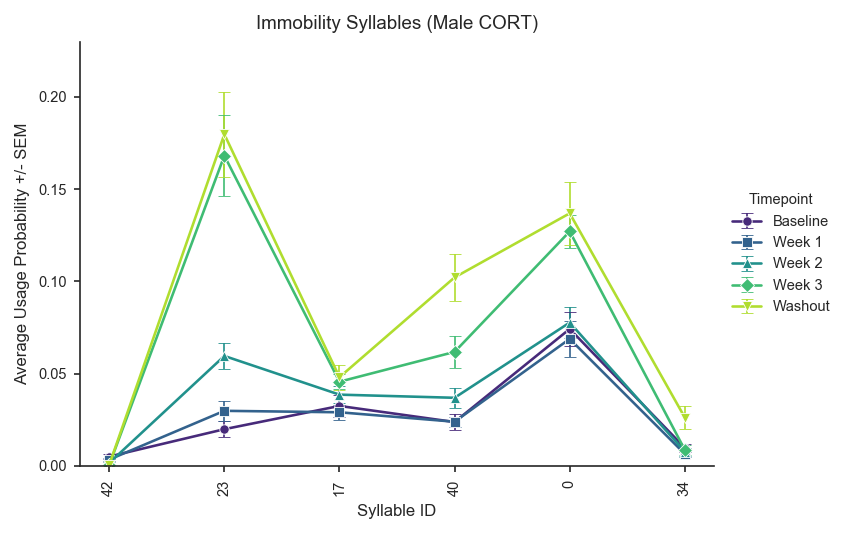

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/hesitation_female.eps


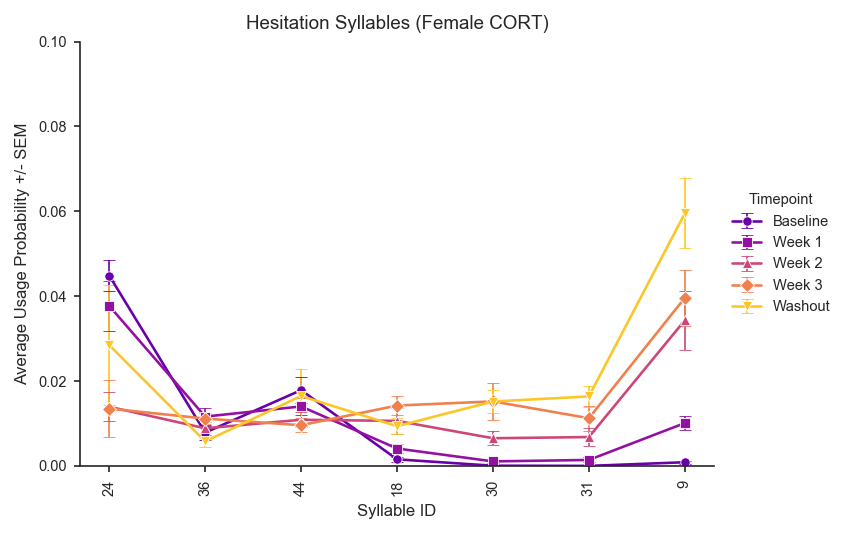

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/hesitation_male.eps


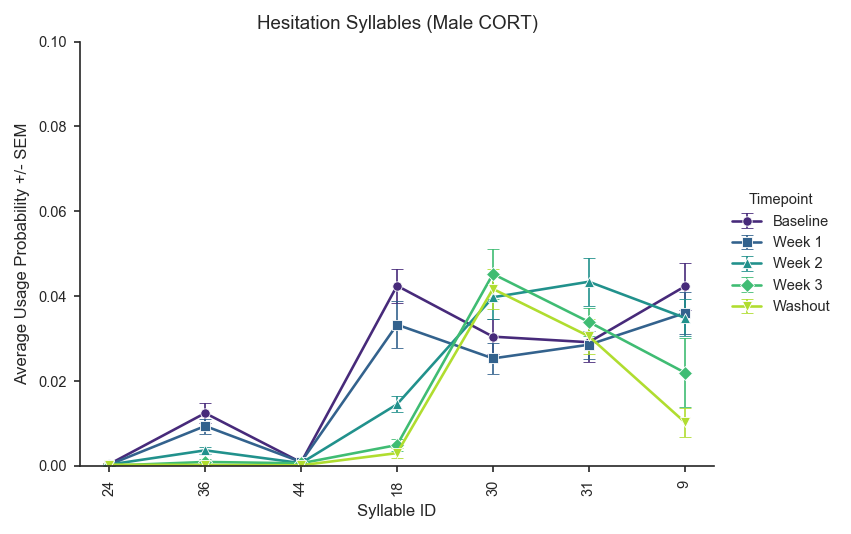

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_exploratory_female.eps


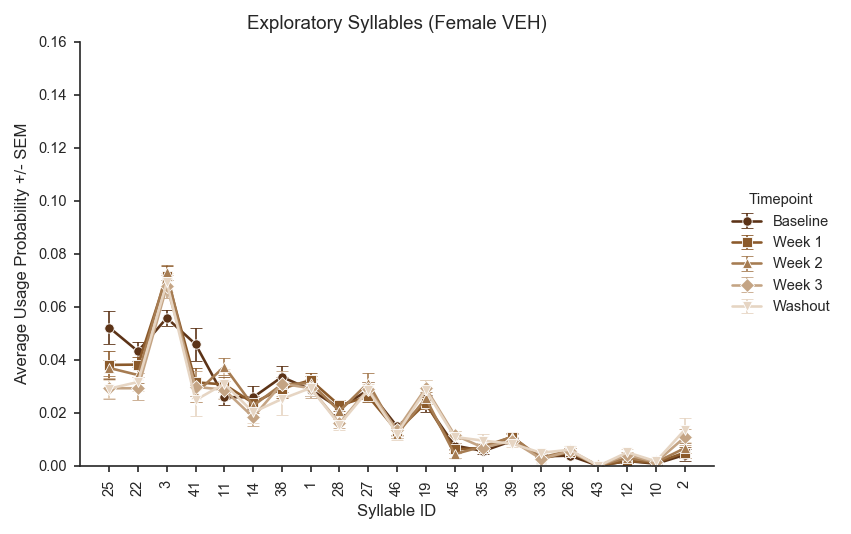

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_exploratory_male.eps


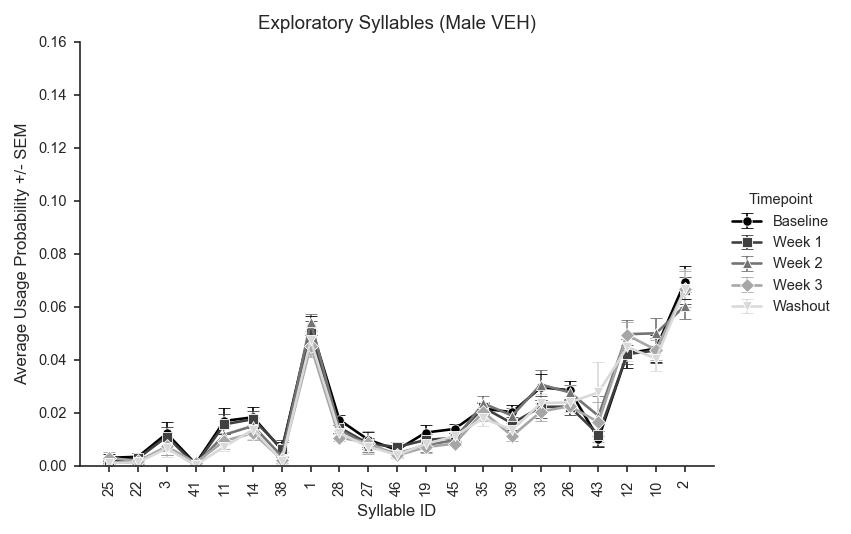

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_locomotion_female.eps


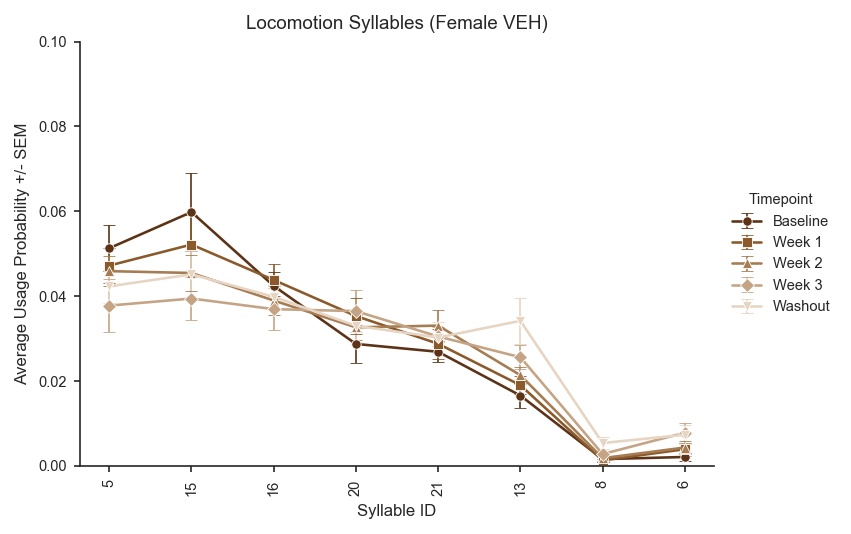

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_locomotion_male.eps


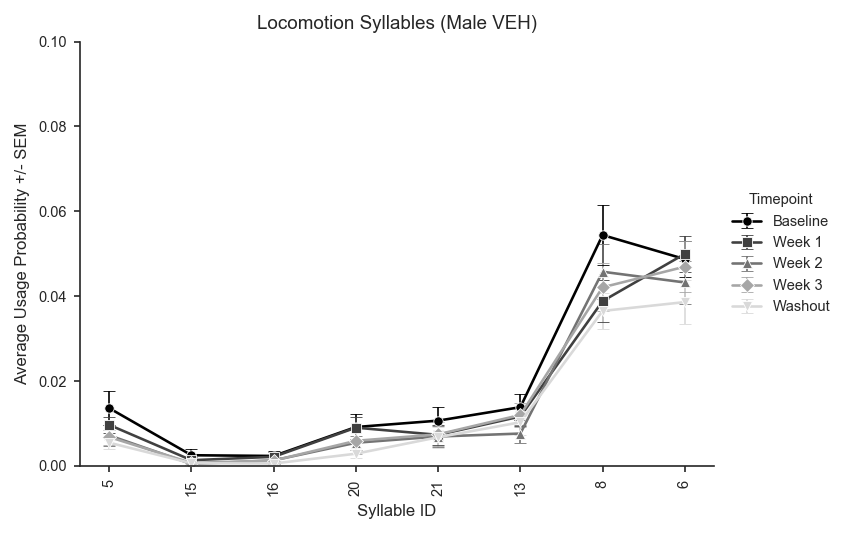

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_grooming_female.eps


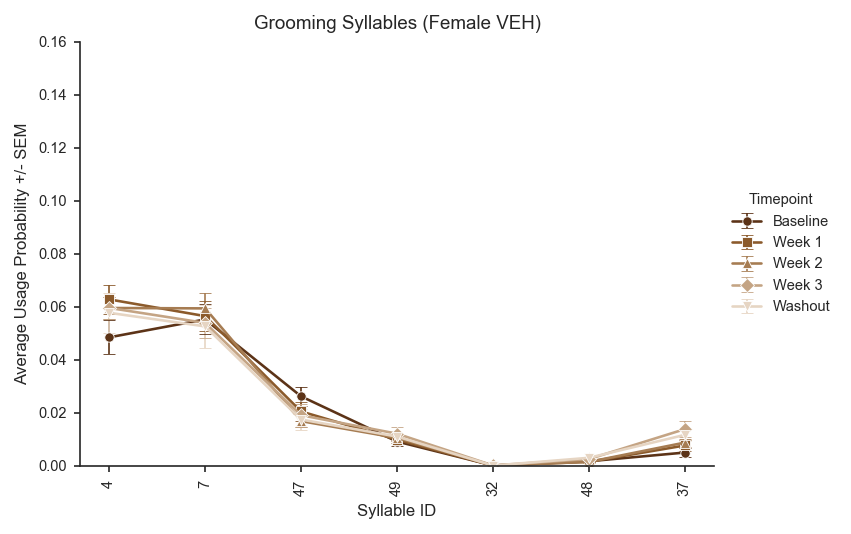

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_grooming_male.eps


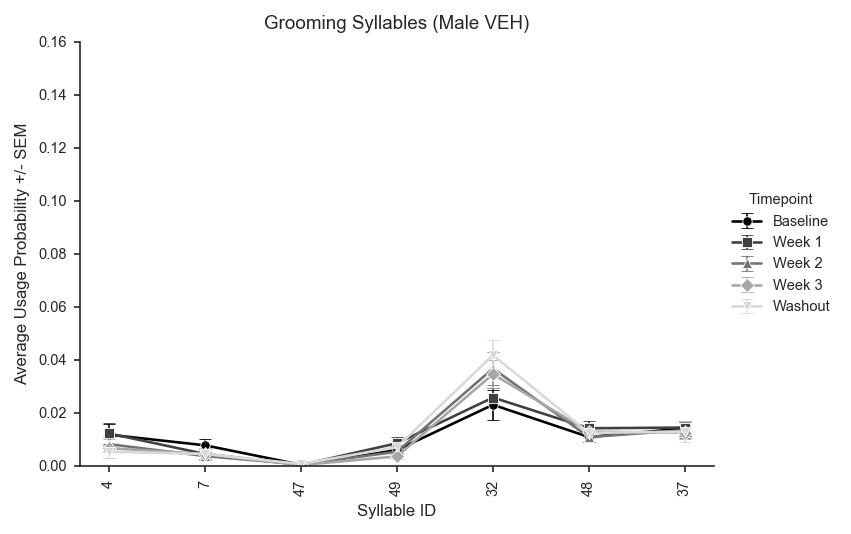

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_immobility_female.eps


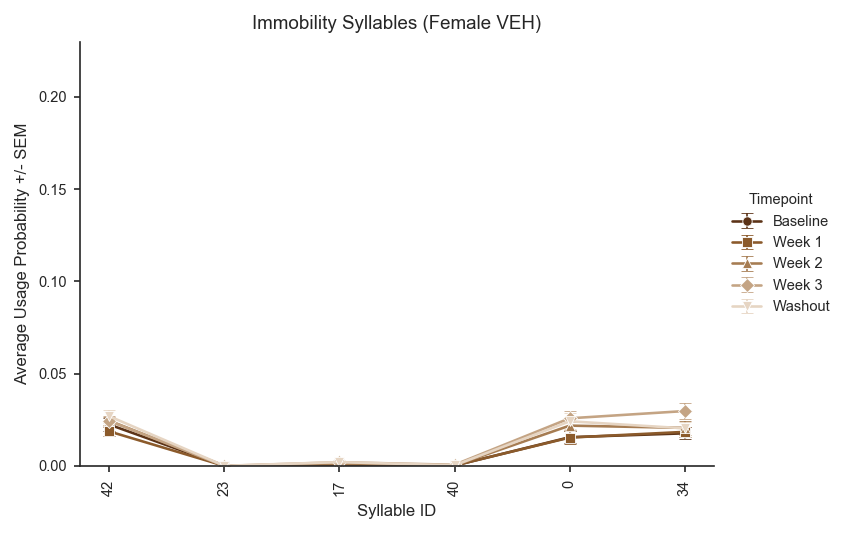

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_immobility_male.eps


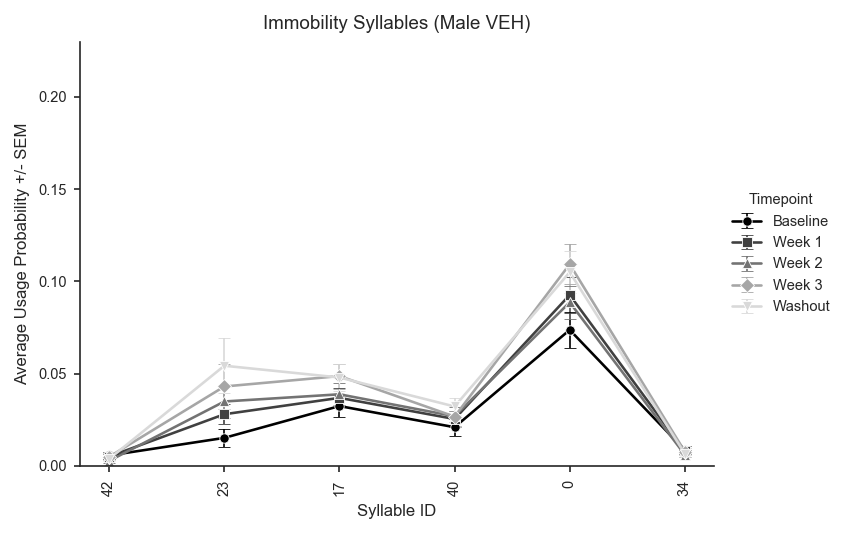

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_hesitation_female.eps


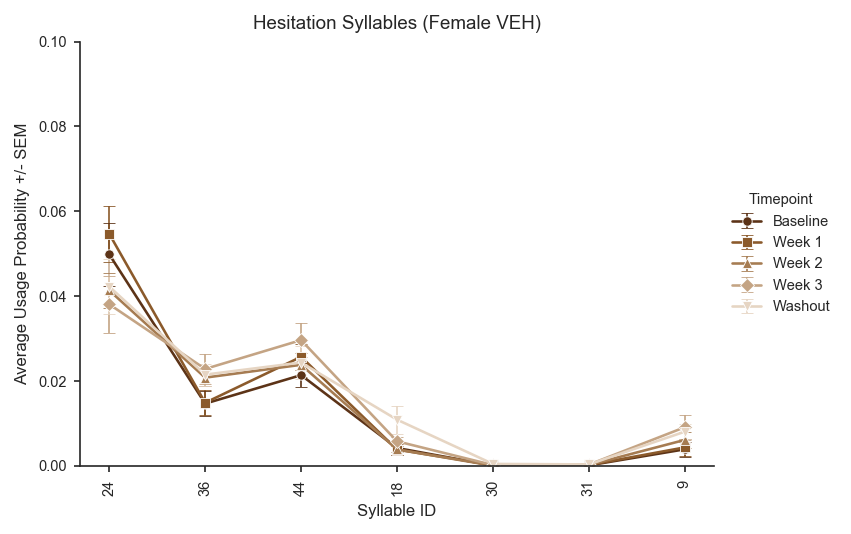

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_hesitation_male.eps


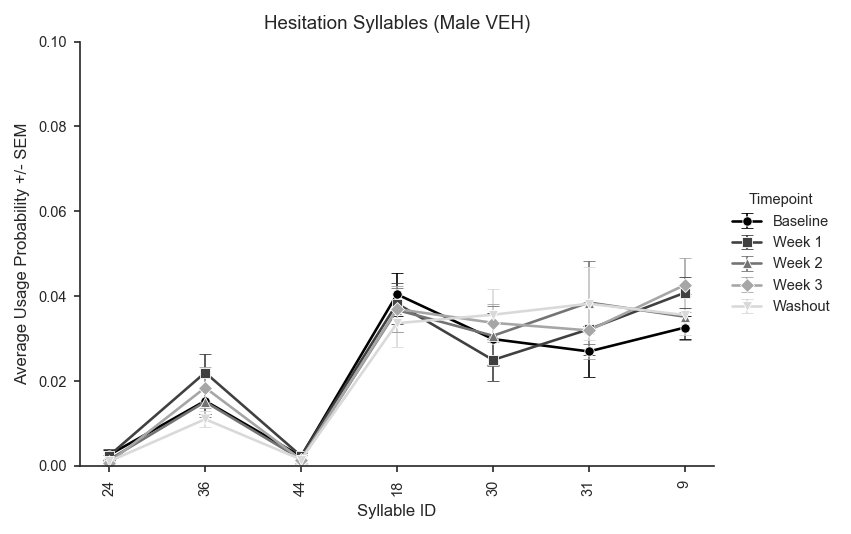

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_male_vs_female_baseline.eps


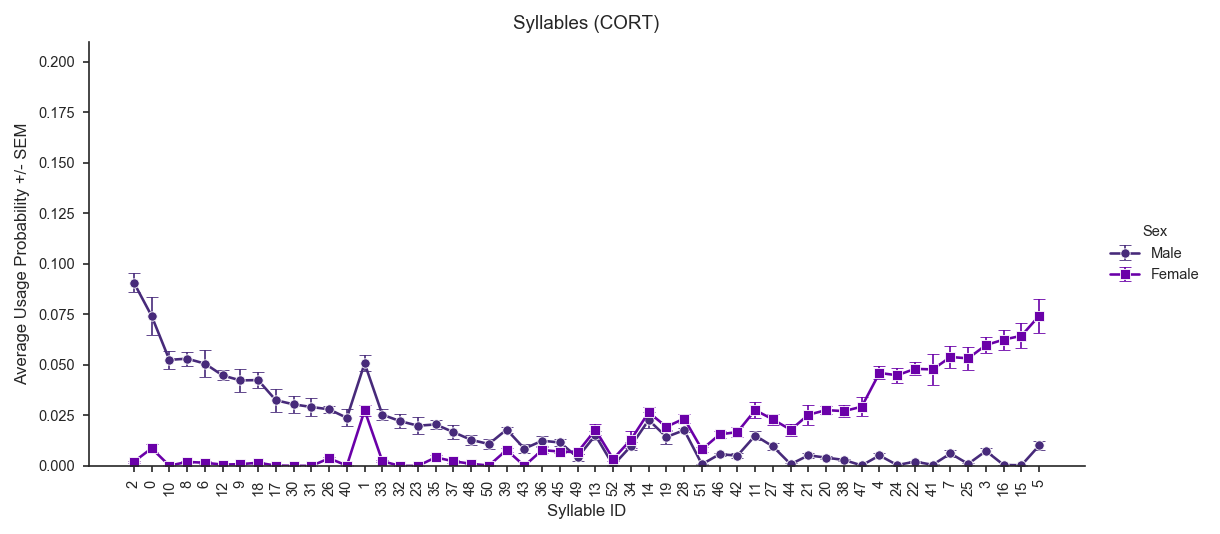

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_male_vs_female_week3.eps


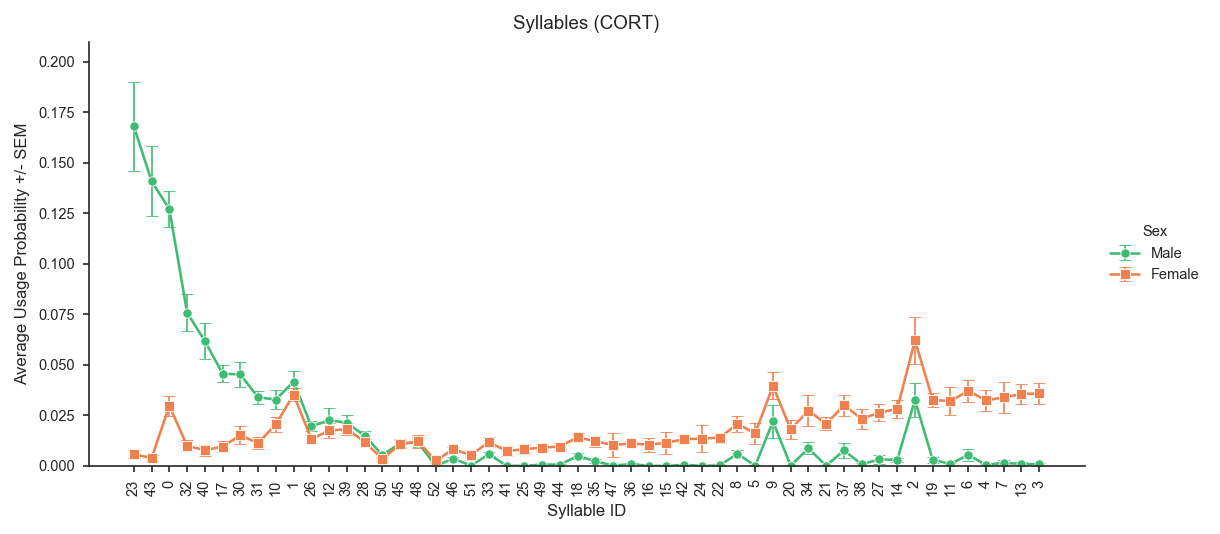

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_male_vs_female_washout.eps


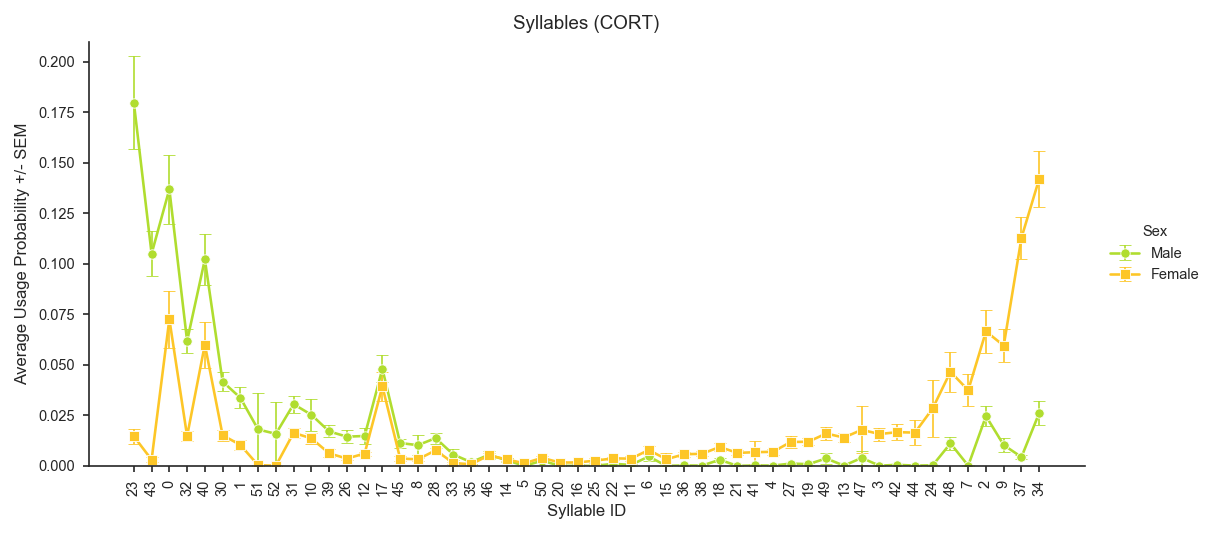

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_male_vs_female_baseline.eps


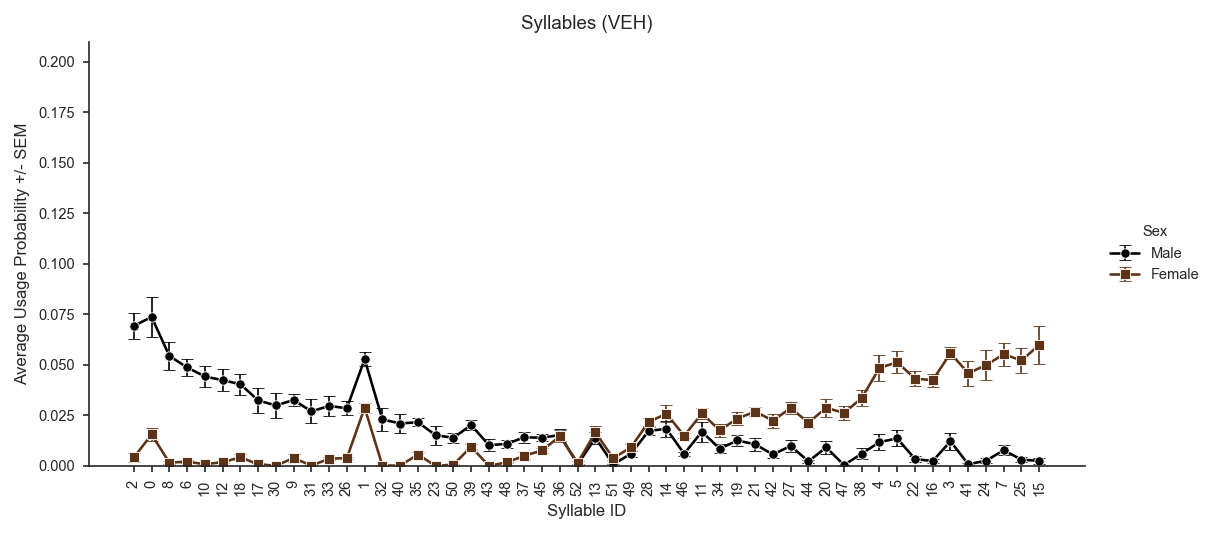

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_male_vs_female_week3.eps


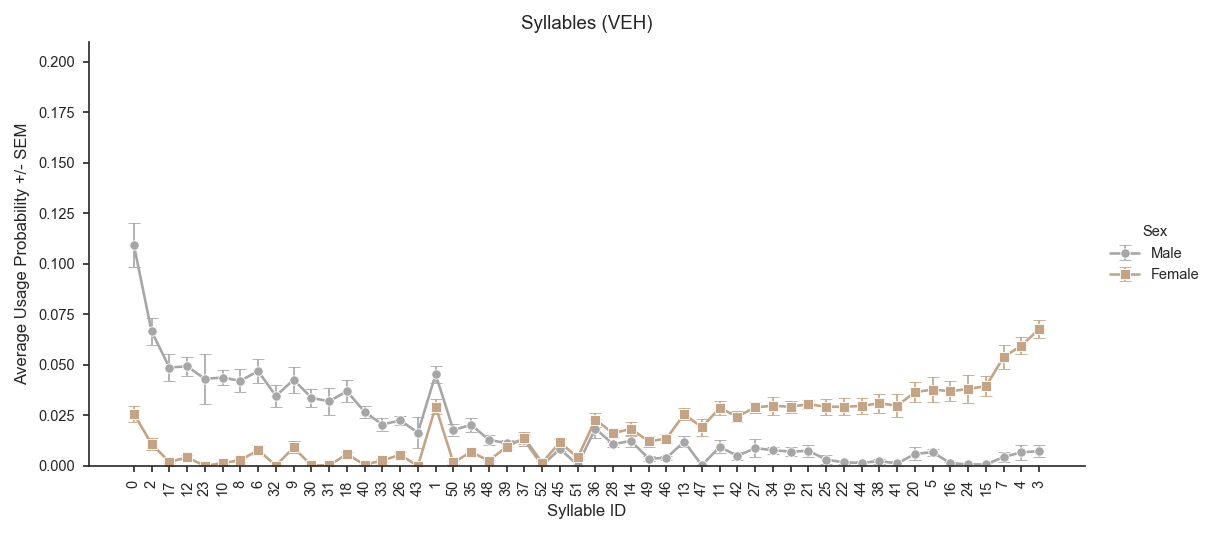

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/veh_male_vs_female_washout.eps


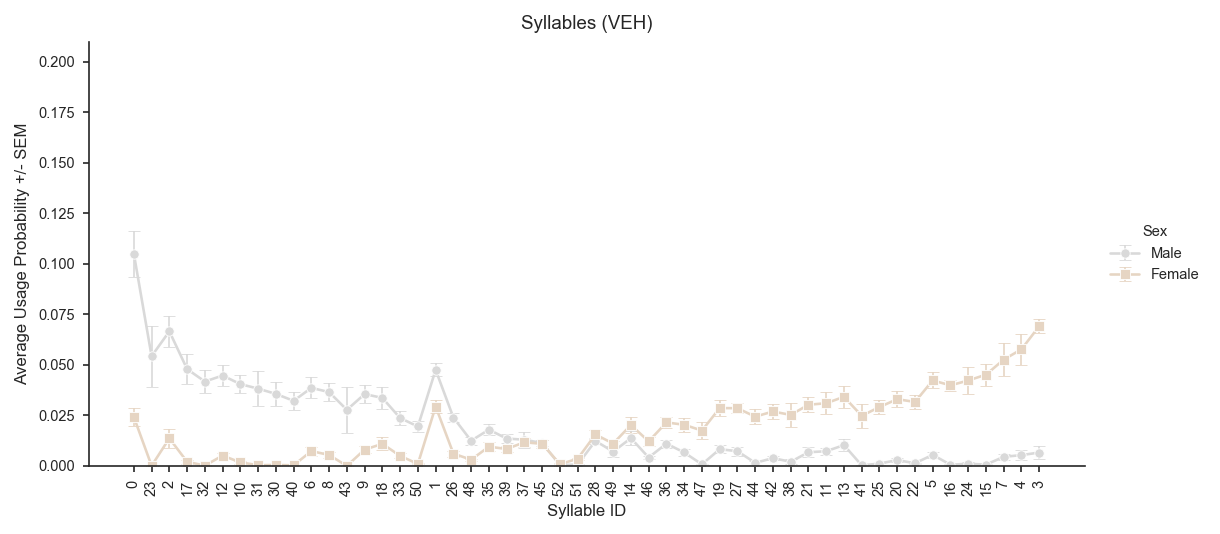

In [6]:
# Shared plot defaults
SORT_BY = ('cort_b2_f', 'cort_washout_f')
EXCLUDE_SYLLABLES = [29]
Y_MAX = 0.16
PLOT_WIDTH = 7

# All syllables over time
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Timepoint', width=10,
    save_path=join(cfg.figures_dir, 'cort_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Timepoint', width=10,
    save_path=join(cfg.figures_dir, 'cort_male.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Timepoint', width=10,
    save_path=join(cfg.figures_dir, 'veh_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Timepoint', width=10,
    save_path=join(cfg.figures_dir, 'veh_male.eps'),
)

# CORT category time series
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=Y_MAX,
    syllable_dict=syllable_dict, categories=['exploratory'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'exploratory_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=Y_MAX,
    syllable_dict=syllable_dict, categories=['exploratory'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'exploratory_male.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.1,
    syllable_dict=syllable_dict, categories=['locomotion'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'locomotion_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.1,
    syllable_dict=syllable_dict, categories=['locomotion'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'locomotion_male.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=Y_MAX,
    syllable_dict=syllable_dict, categories=['grooming'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'grooming_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=Y_MAX,
    syllable_dict=syllable_dict, categories=['grooming'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'grooming_male.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.23,
    syllable_dict=syllable_dict, categories=['immobility'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'immobility_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.23,
    syllable_dict=syllable_dict, categories=['immobility'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'immobility_male.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.1,
    syllable_dict=syllable_dict, categories=['hesitation'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'hesitation_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('cort', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.1,
    syllable_dict=syllable_dict, categories=['hesitation'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'hesitation_male.eps'),
)

# VEH category time series
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=Y_MAX,
    syllable_dict=syllable_dict, categories=['exploratory'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_exploratory_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=Y_MAX,
    syllable_dict=syllable_dict, categories=['exploratory'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_exploratory_male.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.1,
    syllable_dict=syllable_dict, categories=['locomotion'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_locomotion_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.1,
    syllable_dict=syllable_dict, categories=['locomotion'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_locomotion_male.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=Y_MAX,
    syllable_dict=syllable_dict, categories=['grooming'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_grooming_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=Y_MAX,
    syllable_dict=syllable_dict, categories=['grooming'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_grooming_male.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.23,
    syllable_dict=syllable_dict, categories=['immobility'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_immobility_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.23,
    syllable_dict=syllable_dict, categories=['immobility'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_immobility_male.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'f'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.1,
    syllable_dict=syllable_dict, categories=['hesitation'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_hesitation_female.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, cfg.groups_for('veh', 'm'), config=cfg,
    sort_by=SORT_BY, exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.1,
    syllable_dict=syllable_dict, categories=['hesitation'], legend_title='Timepoint', width=PLOT_WIDTH,
    save_path=join(cfg.figures_dir, 'veh_hesitation_male.eps'),
)

# Male vs female at selected timepoints
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, ['cort_b2_m', 'cort_b2_f'], config=cfg,
    sort_by=('cort_b2_m', 'cort_b2_f'), exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Sex', width=10,
    save_path=join(cfg.figures_dir, 'cort_male_vs_female_baseline.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, ['cort_wk3_m', 'cort_wk3_f'], config=cfg,
    sort_by=('cort_wk3_m', 'cort_wk3_f'), exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Sex', width=10,
    save_path=join(cfg.figures_dir, 'cort_male_vs_female_week3.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, ['cort_washout_m', 'cort_washout_f'], config=cfg,
    sort_by=('cort_washout_m', 'cort_washout_f'), exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Sex', width=10,
    save_path=join(cfg.figures_dir, 'cort_male_vs_female_washout.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, ['veh_b2_m', 'veh_b2_f'], config=cfg,
    sort_by=('veh_b2_m', 'veh_b2_f'), exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Sex', width=10,
    save_path=join(cfg.figures_dir, 'veh_male_vs_female_baseline.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, ['veh_wk3_m', 'veh_wk3_f'], config=cfg,
    sort_by=('veh_wk3_m', 'veh_wk3_f'), exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Sex', width=10,
    save_path=join(cfg.figures_dir, 'veh_male_vs_female_week3.eps'),
)
plot_syllable_usage_diff(
    pivot_mean, pivot_sem, ['veh_washout_m', 'veh_washout_f'], config=cfg,
    sort_by=('veh_washout_m', 'veh_washout_f'), exclude_syllables=EXCLUDE_SYLLABLES, y_max=0.21,
    syllable_dict=syllable_dict, legend_title='Sex', width=10,
    save_path=join(cfg.figures_dir, 'veh_male_vs_female_washout.eps'),
)


## 7. Transition matrices (optional)

Expects `{group}_bigram_transition_matrix.csv` files under `cfg.transition_matrix_dir`.


Found 12 transition matrices
Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_b1_f_transition_matrix.eps


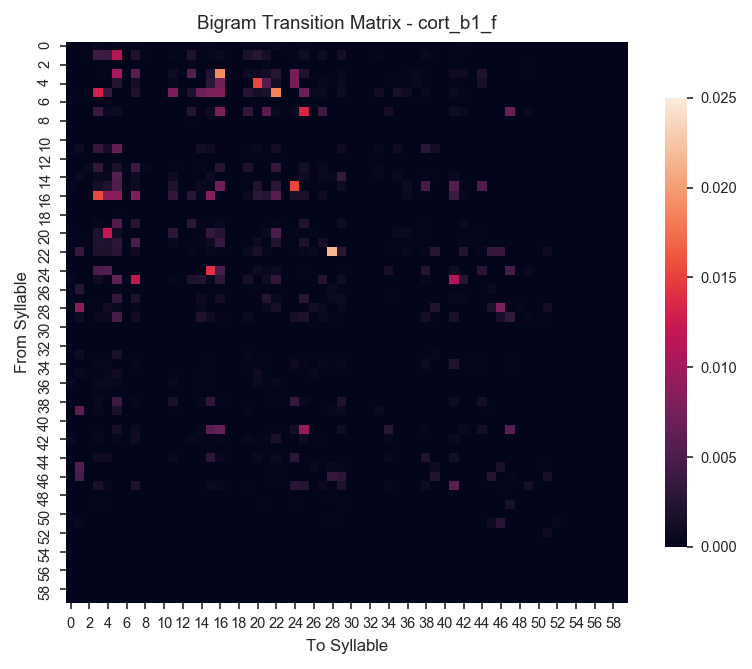

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_b1_m_transition_matrix.eps


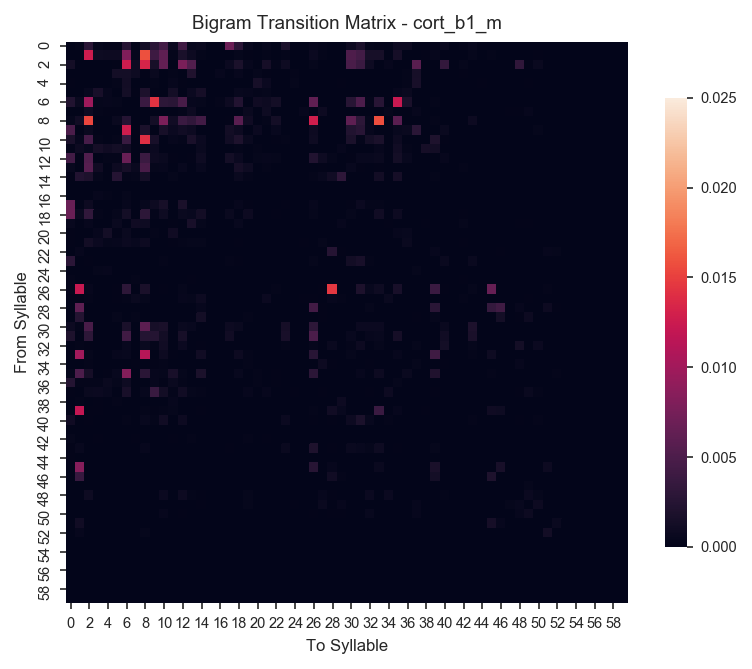

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_b2_f_transition_matrix.eps


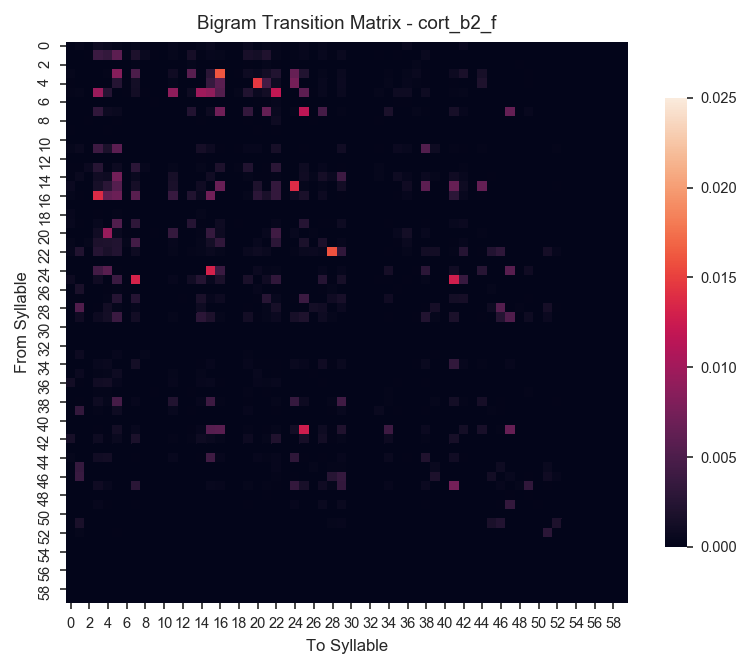

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_b2_m_transition_matrix.eps


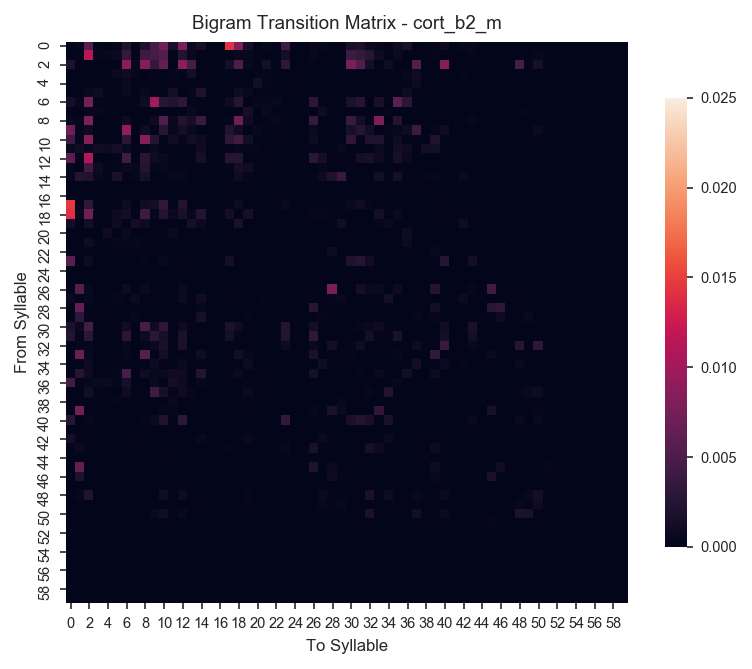

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_washout_f_transition_matrix.eps


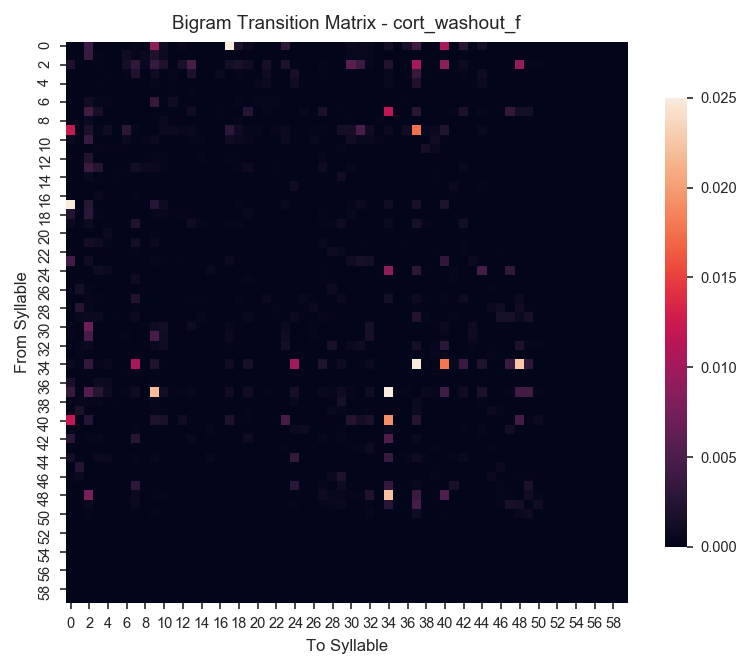

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_washout_m_transition_matrix.eps


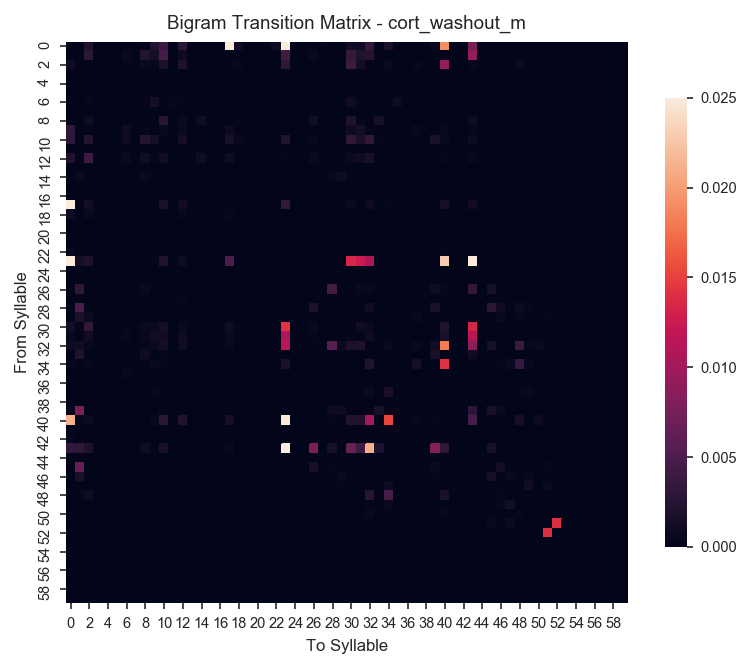

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_wk1_f_transition_matrix.eps


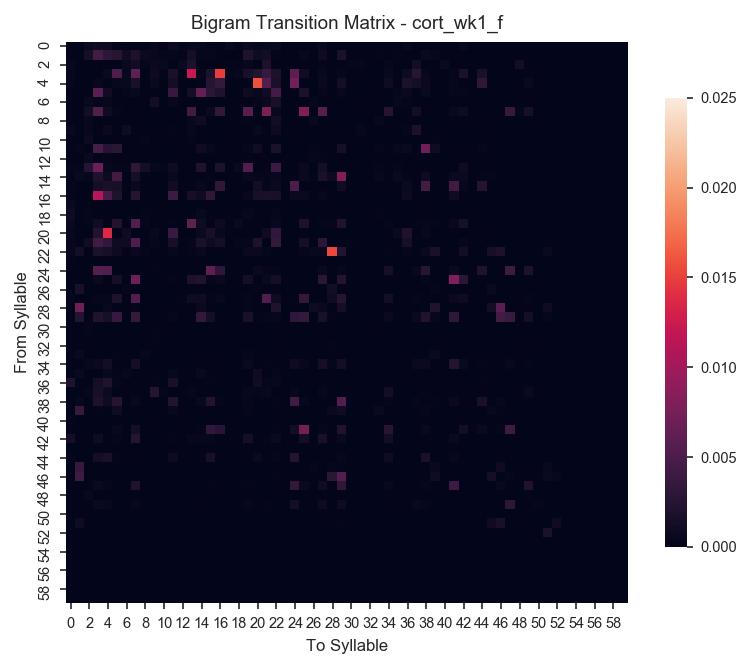

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_wk1_m_transition_matrix.eps


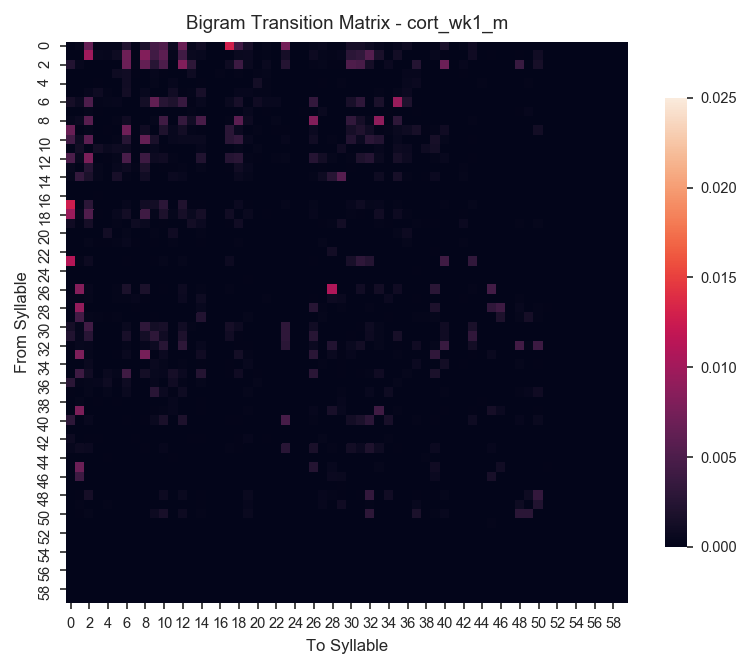

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_wk2_f_transition_matrix.eps


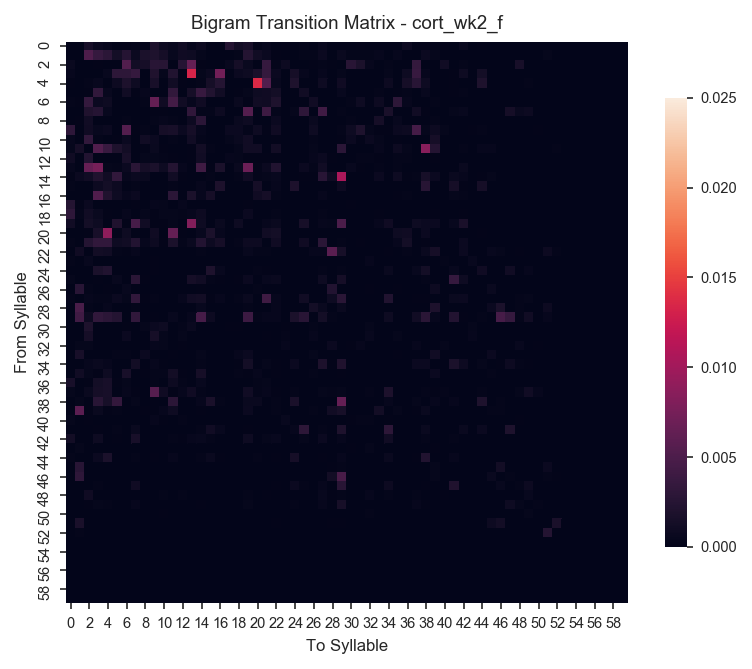

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_wk2_m_transition_matrix.eps


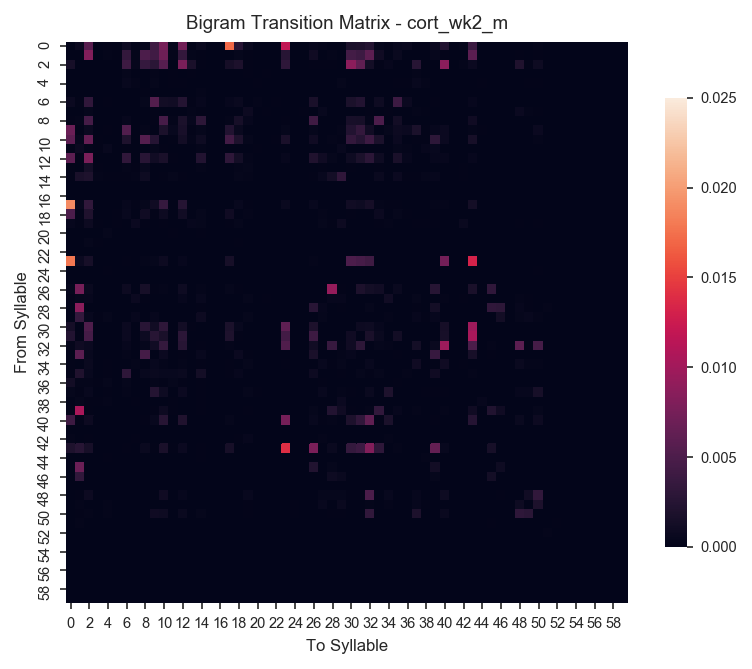

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_wk3_f_transition_matrix.eps


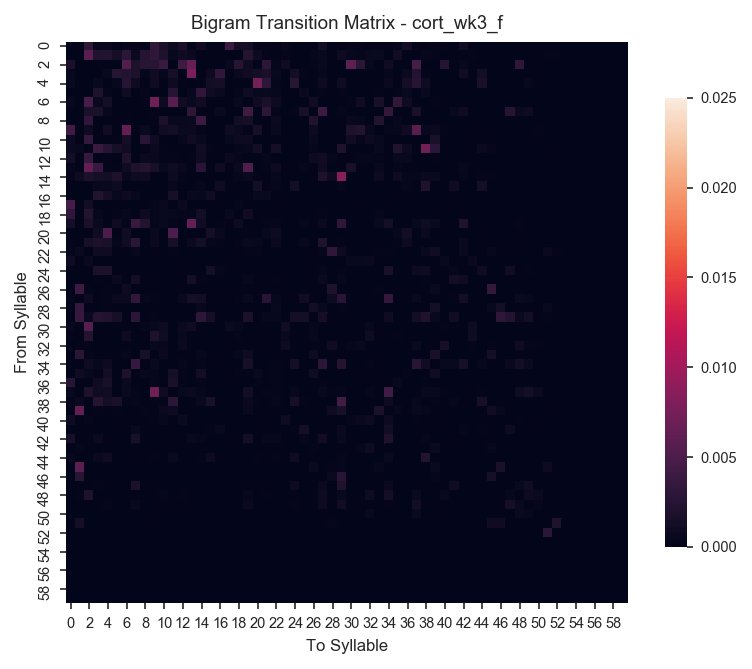

Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/cort_wk3_m_transition_matrix.eps


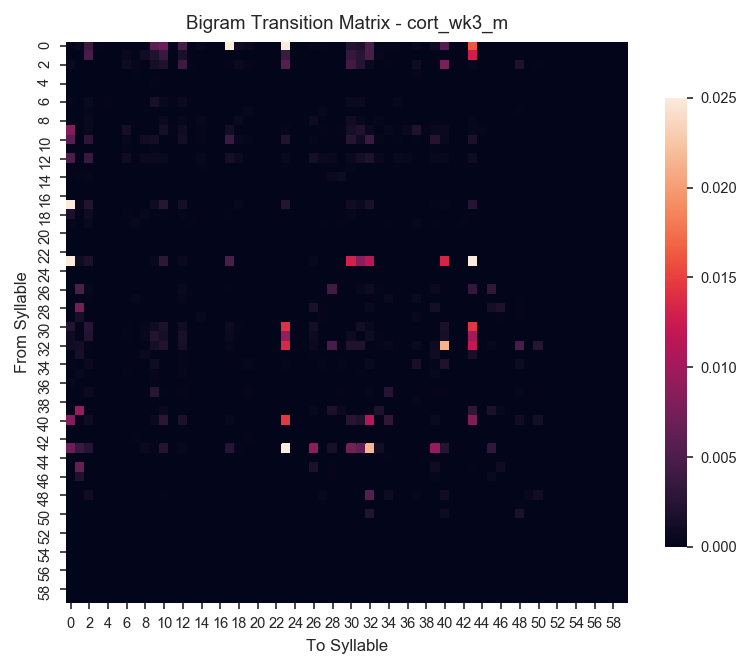

In [7]:
# Include only the groups you want to plot
TRANSITION_INCLUDED_GROUPS = {
    f'{condition}_{sex}'
    for condition in ('cort_b1', 'cort_b2', 'cort_wk1', 'cort_wk2', 'cort_wk3', 'cort_washout')
    for sex in cfg.sex_codes
}

transition_files = list_transition_matrix_files(cfg, TRANSITION_INCLUDED_GROUPS)
print(f'Found {len(transition_files)} transition matrices')

for path in transition_files:
    plot_transition_matrix(path, config=cfg, vmax=0.025)


## 8. Fingerprint plots (optional)

Requires `moseq2_viz` and the large `moseq_df.csv`. Saves PDF / PNG / EPS under `cfg.fingerprint_plot_dir`.


Fingerprint for CORT
Groups: ['cort_b2_m', 'cort_wk1_m', 'cort_wk2_m', 'cort_wk3_m', 'cort_washout_m', 'cort_b2_f', 'cort_wk1_f', 'cort_wk2_f', 'cort_wk3_f', 'cort_washout_f']
Loading stats_df...
Loading moseq_df (chunked filter; file is large)...
  scanned 5,000,000 rows; kept 36,000
  scanned 10,000,000 rows; kept 2,188,017
  scanned 15,000,000 rows; kept 4,272,032
Loaded moseq_df subset: 4,391,957 rows x 33 columns
Saved: /Users/mohanyang/Documents/GitHub/Moseq-Analysis-Visualization/figures/moseq_fingerprint_cort_pretty.pdf / .png / .eps


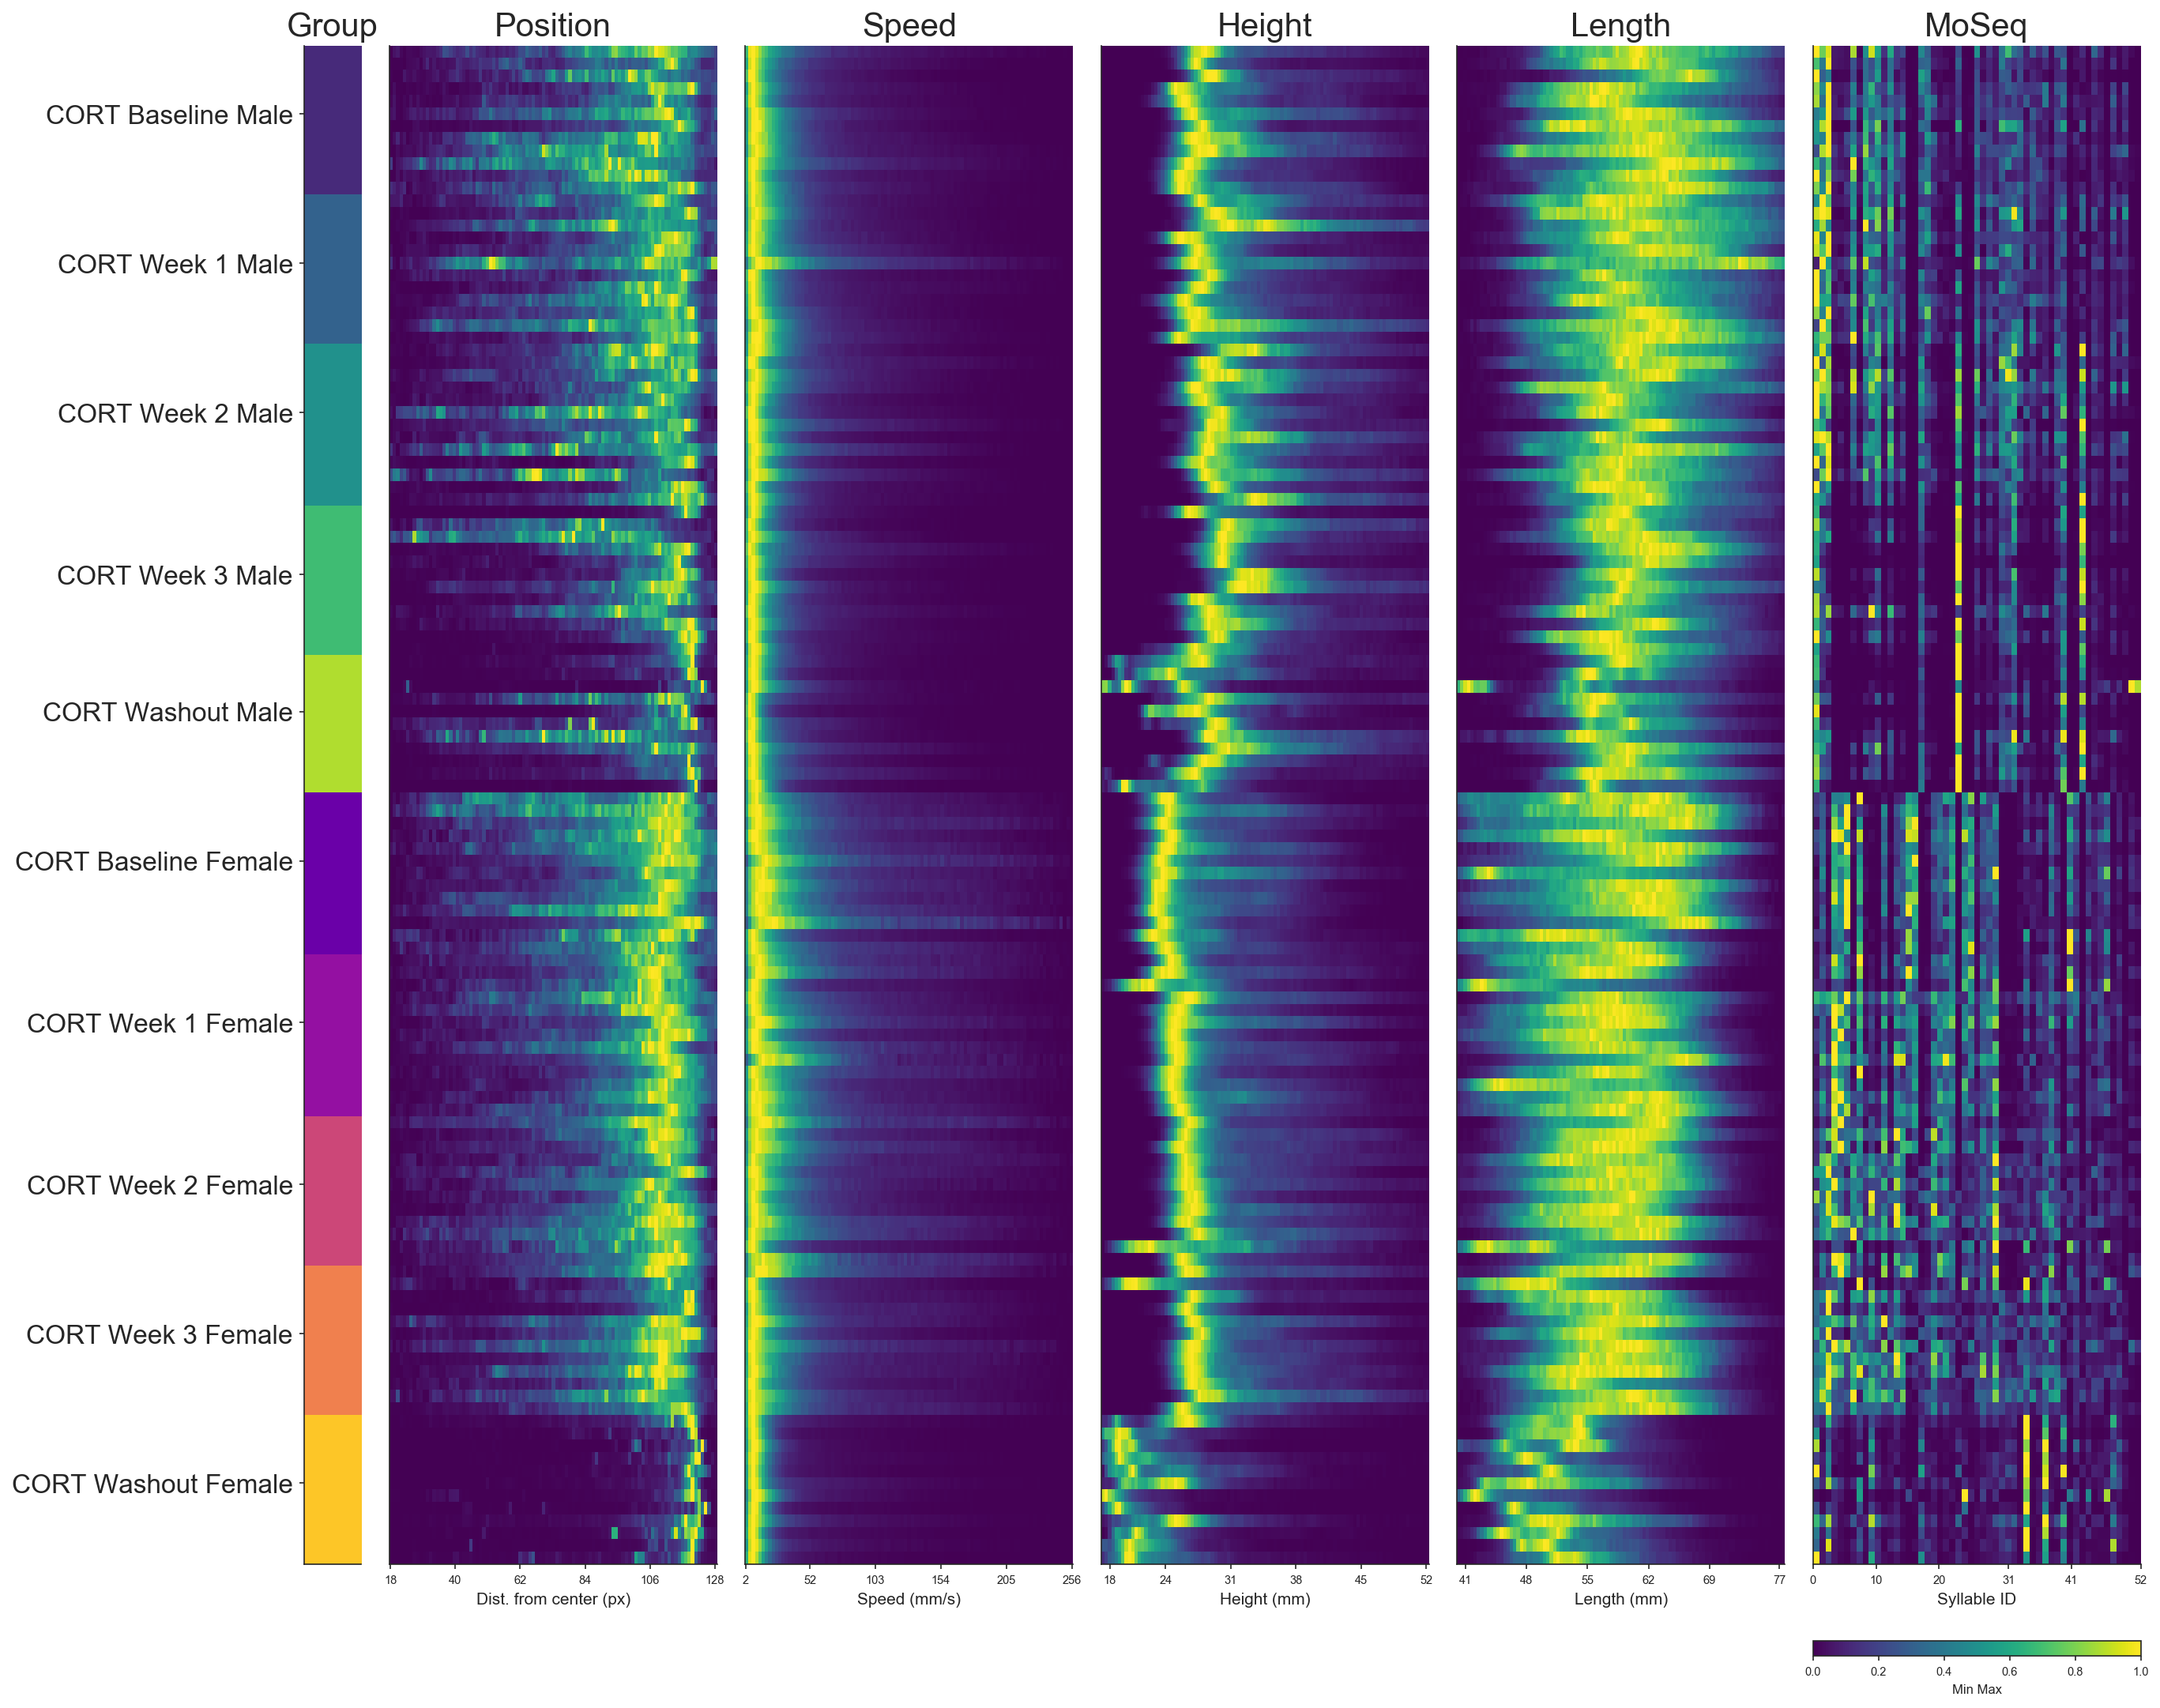

In [8]:
# Uncomment to run (slow: streams moseq_df.csv)
summary_cort, range_dict_cort = run_fingerprint_for_treatment(cfg, 'cort')
# summary_veh, range_dict_veh = run_fingerprint_for_treatment(cfg, 'veh')
